# Lecture 9 - Genetic algorithms and the Traveling Salesman Problem
## The traveling salesman problem (TSP)*
The traveling salesman problem (TSP) consists of a salesman and a set of $N$ cities with positions $\vec{c}_i$. The salesman **has to visit each one of the cities starting from a certain one (e.g. the hometown) and returning to the same city**. The challenge of the problem is that the traveling salesman wants to **minimize the total length of the trip**.

Consider now the ordered sequence of cities, $\vec{c}_1, \vec{c}_2, \dots, \vec{c}_N$, which goes from city 1 to the n$^{th}$ city. The path that minimizes the following loss/cost function:

$$
L^{(2)}(\vec{x}_1, \vec{x}_2, \dots, \vec{x}_N) = \sum_{i=1}^{N} |\vec{x}_i-\vec{x}_{i+1}|^2
$$

or 
$$
L^{(1)}(\vec{x}_1, \vec{x}_2, \dots, \vec{x}_N) = \sum_{i=1}^{N} |\vec{x}_i-\vec{x}_{i+1}|
$$


(with $\vec{x}_{N+1}=\vec{x}_1$) is one particular permutation, P, of the ordered sequence of cities $\vec{c}_1, \vec{c}_2, \dots, \vec{c}_N$, i.e. 

$$
\vec{x}_1, \vec{x}_2, \dots, \vec{x}_N = \vec{c}_{P1}, \vec{c}_{P2}, \dots, \vec{c}_{PN}
$$

Note also that any particular permutation of the ordered sequence of cities can be obtained from the combination of many simple permutations among pairs of cities.

We can express a possible path via a 1D vector whose elements, from the first to the last, are integers that represents the cities in the order in which the salesman would visit them; for example for $N=5$ cities one possible path is represented by the vector:

$$
\left[ 1, 3, 5, 4, 2 \right]
$$

**Alteratively**, we can express a possible path also via a configuration of a $N\times N$ 2D *Ising-like* model with the following bonds:
1. any row must have one and at most one up spin
2. any column must have one and at most one up spin,

all the other spins are down.

We can represent such a configuration with a $N\times N$ matrix whose elements are 1 (spin up) or 0 (spin down); for example, in the case of a TSP with 5 cities:
$$
\begin{bmatrix}
1 & 0 & 0 & 0 & 0\\
0 & 0 & 0 & 0 & 1\\
0 & 1 & 0 & 0 & 0\\
0 & 0 & 0 & 1 & 0\\
0 & 0 & 1 & 0 & 0\\
\end{bmatrix}
$$

You can interpret this matrix in the following way:
- column index represents time of visit: first colum = first visit, etc.
- row index represents the ordered sequence of cities: first row = first city, etc.

the previous matrix thus refers to the following sequence:

$$
\vec{x}_1, \vec{x}_2, \vec{x}_3, \vec{x}_4, \vec{x}_5 = 
\vec{c}_{1}, \vec{c}_{3}, \vec{c}_{5}, \vec{c}_{4}, \vec{c}_{2}
$$

and thus to the following *cost* of the path:

$$
L^{(2)}(\vec{x}_1, \dots, \vec{x}_5) = 
|\vec{c}_1-\vec{c}_3|^2 + |\vec{c}_3-\vec{c}_5|^2 + |\vec{c}_5-\vec{c}_4|^2 +
|\vec{c}_4-\vec{c}_2|^2 + |\vec{c}_2-\vec{c}_1|^2
$$

or
$$
L^{(1)}(\vec{x}_1, \dots, \vec{x}_5) = 
|\vec{c}_1-\vec{c}_3| + |\vec{c}_3-\vec{c}_5| + |\vec{c}_5-\vec{c}_4| +
|\vec{c}_4-\vec{c}_2| + |\vec{c}_2-\vec{c}_1|
$$


Note that, for this *ising-like* representation any particular permutation of the ordered sequence of cities can be obtained by a sequence of multiple pair permutations among rows and/or among columns.

**Warm suggestion: by using the 1D representation** (but you can work with the representation you prefer or the one you are able to invent) ...

### Exercise 09.1

Write a code to solve the TSP with a **Genetic** algorithm (GA). Note that you should invent **some** *genetic-mutation* operators and a *genetic-crossover* operator which should preserve the bonds of the problem: the salesman must visit one and only one time every city and must be back to the first city in the end of the path.

Once the data structure of your code is ready, before you start coding your genetic operators, I warmly suggest you to code the creation of the starting population and to code a **check function** that verifies if every *individual* fulfils the bonds. Then check your starting population ... and use your check function every time you create a new individual.

You have to invent also a **selection** operator. 
The fitness and thus the order of the population should be obtained from $L^{(2)}(\vec{x}_1, \vec{x}_2, \dots, \vec{x}_N)$ or $L^{(1)}(\vec{x}_1, \vec{x}_2, \dots, \vec{x}_N)$. Once your starting population has been ordered on a fitness basis,
you have 2 possibilities:
1. write a selection operator which obtain the probability to select an individual from $L^{(2)}(\vec{x}_1, \vec{x}_2, \dots, \vec{x}_N)$ or $L^{(1)}(\vec{x}_1, \vec{x}_2, \dots, \vec{x}_N)$
2. write a selection operator which simply uses the order in the orderd population with $M$ individuals, e.g. select the individual $j$ with the algorithm: $j= int(M \times r^p)+1$ where $r$ is a uniform random number $r\in[0,1)$ and $p$ a convenient exponent. 

Set the first city to always appear at position 1, so as to reduce the degeneration of the shortest route to be 2, which corresponds to walking the shortest route in clockwise and anti-clockwise directions.

Then you can start introducing some *genetic-mutation* operators, for example:
1. pair permutation of cities (except for the first city), e.g. $\left[ 1, 2, 3, 4, 5 \right] \to \left[ 1, 2, 4, 3, 5 \right]$ (At this point you should already have such operator ... how have you generated the starting population?).
2. shift of $+n$ positions for $m$ contiguous cities (except for the first city and $m \lt N-1$), e.g. $\left[ 1, 2, 3, 4, 5 \right] \to \left[ 1, 4, 5, 2, 3 \right] $ for a $+2$ shift of the second and third cities.
3. permutation among $m$ contiguous cities (except for the first city) with other (different!) $m$ contiguous cities ($m<N/2$), e.g. $\left[ 1, 2, 3, 4, 5 \right] \to \left[ 1, 4, 5, 2, 3 \right] $ for a permutation of the second and third cities with the last 2.
4. inversion of the order in which they appear in the path of $m$ cities (except for the first city and $m \le N$), e.g. $\left[ 1, 2, 3, 4, 5 \right] \to \left[ 1, 4, 3, 2, 5 \right]$ for the inversion of the cities from 2 to 4.

Every mutation will have its probability, $p^{(i)}_m$ to be called and typically $p^{(i)}_m < 10\%$, but before to include crossover you can check if the GA is able to perform a good *random search* using only mutation operators (in this case $p^{(i)}$ could be higher than in the previous suggestion).

At this point you can add a *crossover* operator (that fulfils the bonds and that you will call with probability $p^{(i)}_c > 50\%$):

given a selected mother and father, e.g. 
$$
\left[ 1, 2, 3, 4, 5 \right]\\
\left[ 1, 5, 4, 3, 2 \right] 
$$
1. cut their paths at the same position:
$$
\left[ 1, 2, 3 | 4, 5 \right]\\
\left[ 1, 5, 4 | 3, 2 \right] 
$$
2. conserve the first part of the paths:
$$
\left[ 1, 2, 3 | X, Y \right]\\
\left[ 1, 5, 4 | X, Y \right] 
$$
3. complete the paths with the missing cities adding them in the **order** in which they appear in the consort:
$$
\left[ 1, 2, 3 | 5, 4 \right]\\
\left[ 1, 5, 4 | 2, 3 \right] 
$$

Here you are: you have two sons that you can add to the new generation ... and so on!

Apply your code to the optimization of a path among 

- 34 cities randomly placed **on** a circumference
- 34 cities randomly placed **inside** a square

Show your results via:

- a picture of $L^{(2)}$ (or $L^{(1)}$) of the best path and of $\langle L^{(2)}\rangle$ (or $\langle L^{(1)}\rangle$), averaged on the best half of the population, as a function of the iterations/generations of your algorithm
- a picture of the best path in cartesian coordinates

## Exercise 9.1 - Theory and solution 

### Introduction to Genetic Algorithms

This code implements a Genetic Algorithm (GA), a class of optimization methods originally introduced by John Holland in the 1960s and further developed in the following decades.

Genetic algorithms are population-based, evolutionary techniques designed to iteratively refine candidate solutions to an optimization problem. Starting from an initial set of randomly generated individuals, each generation is evaluated through a fitness function that quantifies solution quality. The most suitable individuals are then probabilistically selected and used to generate a new population via genetic operators such as recombination and mutation. The process repeats until a predefined termination criterion is satisfied.

The underlying principle of GAs is inspired by biological evolution, particularly the mechanisms of natural selection and adaptation. The candidate solutions that exhibit  higher fitness are more likely to persist and propagate theirselves across generations. This evolutionary process drives the population toward increasingly effective solutions.

A key point of genetic algorithms lies in their ability to balance two complementary search strategies
1. Intensification $\rightarrow$ which concentrates exploration in promising regions of the solution space
2. Diversification $\rightarrow$ which maintains genetic variability to explore new areas and reduce the risk of premature convergence to local optima. 

This balance makes GAs for specific complex problems where traditional optimization approaches may struggle.

Genetic Algorithms are different from other optimization techniques in four ways:
1. They do not use directly the parameters, they use a coded version of them
2. They search a group of solutions
3. They use directly the cost function, no other informations are needed
4. They use probabilistic transition rules, not deterministic rules



### Population and operators
In a genetic algorithms different structures are implemented:
- **Chromosome** $\rightarrow$ a complete candidate solution; in this case, an ordered sequence (vector) representing the tour of cities
- **Population** $\rightarrow$ a collection of chromosomes at a given generation
- **Genes** $\rightarrow$ a single component of a chromosome; here, it corresponds to a position in the tour sequence
- **Alleles** $\rightarrow$ a possible value that a gene can assume; for the TSP, this corresponds to a specific city (excluding the fixed starting city)

The simplest form of a genetic algorithm relies on three main operators: selection, crossover, and mutation.

1. **Selection** $\rightarrow$ chromosomes  are selected from the population based on their fitness. Shorter routes correspond to higher fitness and are therefore more likely to be chosen for reproduction.

2. **Crossover** $\rightarrow$ two parent paths are combined to generate offspring while preserving the sequences' characteristics (i.e. each city is visited once). This is done by exchanging portions of the tow parents' genetic material after a specified crossover point.

3. **Mutation** $\rightarrow$ this operator introduces random changes in randomly selected individual genes. Mutation increases diversity in the population and helps prevent premature convergence.

### The algorithm
Here is presented a simple workflow of a GA 
1. Start with a randomly generated population of $n$ chromosomes of length $l$ 
2. Compute the fitness $f(x)$ of each chromosome $x$ in the population
3. Select a pair of parent chromosomes from the actual population and the probability of selection is an increasing function of fitness.
Given $p_c$ the probability of producing a crossover on the pair at a randomly chosen point to form two offspring. We note that if no crossover takes place the two offspring would be the exact copies of the parents.
Then we implement a mutation with probability $p_m$ and we place the resulting chromosomes in the new population.

The steps in 3 are iterated until $n$ offspring are created.

4. The previous population is replaced with the newly created one.
5. Then we repeat this process from the step 2

### The Schema Theorem
In genetic algorithms, good solutions are often composed of smaller, highly fit substructures, commonly referred to as building blocks. This idea is formalized through the concept of a schema $H$, introduced by Holland to describe patterns shared among chromosomes.

A schema is an equivalence class of chromosomes represented by a template over the alphabet {0,1,∗}, where 
"∗" denotes a "non-relevant value" position. In this representation, only some gene positions are fixed, while others can take any value. All chromosomes matching the template are called instances of the schema. For example, the schema 
H=[1∗∗∗∗1] represents all binary strings of length 6 that start and end with 1.

Two key quantities characterize a schema:

- Order $o(H)$ $\rightarrow$ the number of fixed (non-∗) positions in the schema, i.e., the number of specified genes.
- Defining length $d(H)$ $\rightarrow$ the distance between the first and last fixed positions, measuring how spread out the relevant information is.

E.g. the schema H=[1∗∗∗∗1] has order $o(H)=2$ and defining length  $d(H)=5$.

Schemas are a key point to understand how genetic algorithms process information. Any given population of $n$ strings contains instances of between $2^l$ (i.e. maximal homogeneity) and $n\cdot 2^l$ (i.e. maximal diversity) different schemas. Thus leading to the estimation of the average fitness of a much larger number of schemas, at a given generation, rather than evaluating explicitly the fitnesses of the $n$ strings in the population.
This means that GAs operate as a form of implicit parallelism, sampling and propagating many patterns at once.

This behavior is formally captured by the Schema Theorem which says that “short,low-order schemas whose average fitness remains above the mean will receive exponentially increasing numbers of samples (i.e., instances evaluated) over time”. The Schema Theorem is a lower bound, since it deals only with the destructive effects of crossover and mutation.


## Code structure

The project is structured into two main classes that separate the logic of a single solution from the logic of the entire population: individual and system.

### `Individual` Class

The **`Individual` class** represents a single candidate solution (a path) within the Genetic Algorithm. It encapsulates the "genetic material" of the path and defines how that material can mutate and be evaluated.

Each individual is characterized by a sequence of cities that must satisfy strict topological constraints:

* The path is stored as an Armadillo `uvec` (unsigned vector). Each element corresponds to a city index.
* To reduce the search space and eliminate redundant solutions (e.g., the same loop starting at different cities), the first city is fixed (index 0). 
* `check` $\rightarrow$ every genetic operation is followed by a check to ensure that:
    1. The sequence always begins with city $0$
    2. Every city index appears exactly once


The "quality" of an individual is determined by its total path length, the fitness. The goal of the GA is to minimize this value:

$$L^{(1)}(\vec{x}_1, \dots, \vec{x}_N) = \sum_{i=1}^{N-1} D_{x_i, x_{i+1}} + D_{x_N, x_1}$$

where $D_{i,j}$ is the distance taken from the pre-calculated distances matrix. The final term ensures the periodic boundary conditions (so that the salesman returns back to the first city.

To better explore the fitness landscape four mutation operators are implemented. Each operator acts only on the indices greater than 0 to preserve the starting city.

* Pair permutation $\rightarrow$ selects two random cities and swaps their positions in the sequence.
* Shift $\rightarrow$ picks a contiguous block of $m$ cities and shifts it forward by $n$ positions.
* Contiguous permutation $\rightarrow$ swaps two distinct, non-overlapping blocks of cities of the same length $m$.
* Inversion $\rightarrow$ reverses the order of cities within a randomly selected sub-sequence (e.g., `[1, 2, 3, 4]` becomes `[4, 3, 2, 1]`).

The `initialize` method creates a valid random starting path by:
1. Filling the vector with an ordered sequence $[0, 1, 2, \dots, N-1]$.
2. Performing multiple random swaps between indices $1$ and $N-1$.
3. Calculating the initial fitness to set a baseline for the first generation.

--- 
### `System` Class

The `System` class is the key part of the GA, it manages the environment and drives the population through generations.
Before the evolution begins, the system defines the problem space and pre-computes the distance matrix:

* Cities are generated in two distinct configurations:
    * `circle`: Randomly distributed on a circumference ($r=1$). The optimal solution is the perimeter.
    * `square`: Uniformly distributed within a square ($l=2$). This tests the GA on a complex, non-analytical landscape.
* To avoid redundant calculations during fitness evaluations, the system pre-computes an $N \times N$ matrix:
    $$D_{i,j} = \sqrt{(x_i - x_j)^2 + (y_i - y_j)^2}$$
    This allows the fitness function to perform a simple memory lookup for the distance between any two cities.

The core of the class is the `new_generation()` method, which transforms the current population into a more fit successor.

* Rank selection $\rightarrow$ to navigate the search space, the system uses a biased selection probability:
    $$\text{index} = \text{int}(N_{pop} \cdot r^p)$$
    By setting **$p = 3.0$**, the algorithm applies high selective pressure. Since $r \in [0,1)$, the cubic power heavily biases the selection toward the shortest paths in the sorted population.
* Reproduction workflow:
    1.  Crossover ($70\%$) $\rightarrow$ parents exchange genetic sequences while respecting the "visit-once" constraint.
    2.  Mutations ($20\%$) $\rightarrow$ four operators (Swap, Shift, Permutation, Inversion) introduce diversity to prevent stagnation in local minima.
    3.  Elitism via sorting $\rightarrow$ the population is re-sorted by fitness after every generation to identify the new "best" path.

The following values were defined for the optimization

| Hyperparameter | Value | Role |
| :--- | :--- | :--- |
| **$N_{cities}$** | $34$ | Number of nodes|
| **$N_{pop}$** | $200$ | Number of candidate solutions maintained per generation |
| **$N_{gen}$** | $600$ | Total iterations allowed for convergence |
| **$P_{mutation}$** | $0.20$ | Probability for each individual mutation operator |
| **$P_{crossover}$** | $0.70$ | Probability of generating offspring via recombination |

The code saves data to monitor:
* Best fitness, so the length of the absolute shortest path found.
* Average best-half, the average fitness of the top $50\%$ of the population.

*Note*: when the average of the best half collapses toward the absolute best fitness, it indicates that the population has reached a high degree of convergence.

In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib import cm
from matplotlib.patches import Rectangle
from matplotlib.collections import LineCollection
plt.style.use('default')

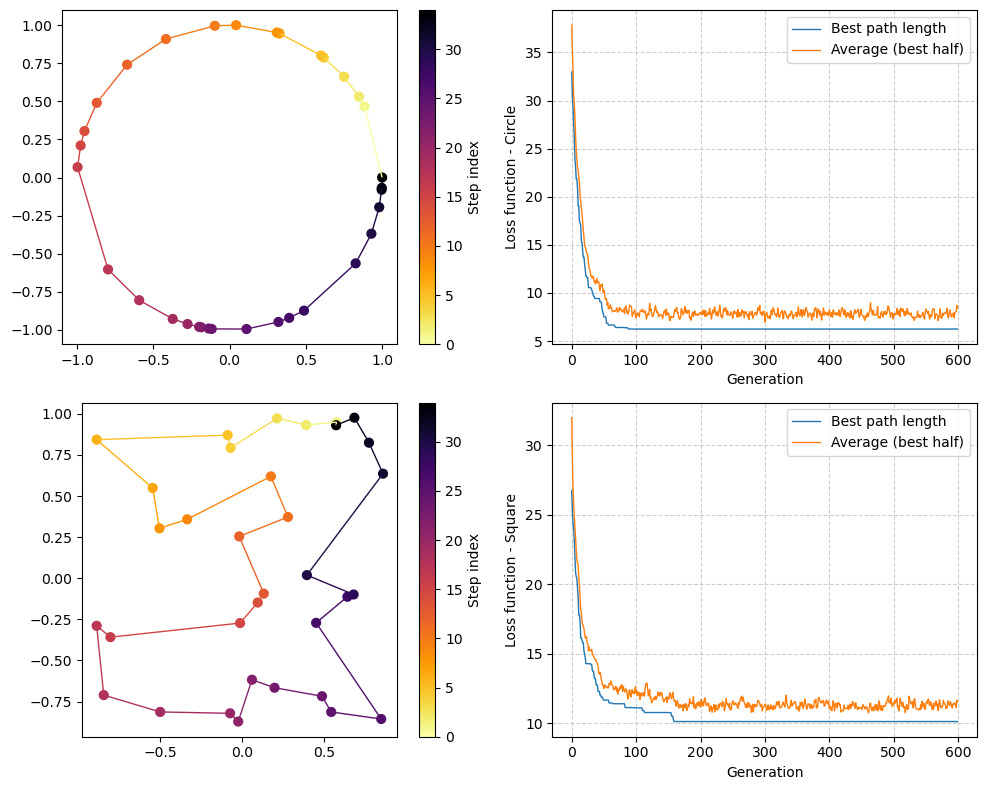

In [4]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

data = np.loadtxt("circle_best_path.dat")
x = data[:, 0]
y = data[:, 1]

points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
lc = LineCollection(segments, cmap='inferno_r', linewidth=1, array=np.arange(len(x)))
axs[0,0].add_collection(lc)

sc = axs[0,0].scatter(x, y, c=np.arange(len(x)), cmap='inferno_r', s=40)
axs[0,0].set_aspect('equal')
fig.colorbar(sc, ax=axs[0,0], label="Step index") 

data = np.loadtxt("circle_losses.dat")
gen  = data[:,0]
best = data[:,1]
avg  = data[:,2]

axs[0,1].plot(gen, best, label="Best path length", linewidth=1)
axs[0,1].plot(gen, avg, label="Average (best half)", linewidth=1)

axs[0,1].set_xlabel("Generation")
axs[0,1].set_ylabel("Loss function - Circle")
axs[0,1].legend()
axs[0,1].grid(True, linestyle='--', alpha=0.6)

data = np.loadtxt("square_best_path.dat")
x = data[:, 0]
y = data[:, 1]

points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
lc = LineCollection(segments, cmap='inferno_r', linewidth=1, array=np.arange(len(x)))
axs[1,0].add_collection(lc)

sc = axs[1,0].scatter(x, y, c=np.arange(len(x)), cmap='inferno_r', s=40)
axs[1,0].set_aspect('equal')
fig.colorbar(sc, ax=axs[1,0], label="Step index")  

data = np.loadtxt("square_losses.dat")
gen  = data[:,0]
best = data[:,1]
avg  = data[:,2]

axs[1,1].plot(gen, best, label="Best path length", linewidth=1)
axs[1,1].plot(gen, avg, label="Average (best half)", linewidth=1)

axs[1,1].set_xlabel("Generation")
axs[1,1].set_ylabel("Loss function - Square")
axs[1,1].legend()
axs[1,1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

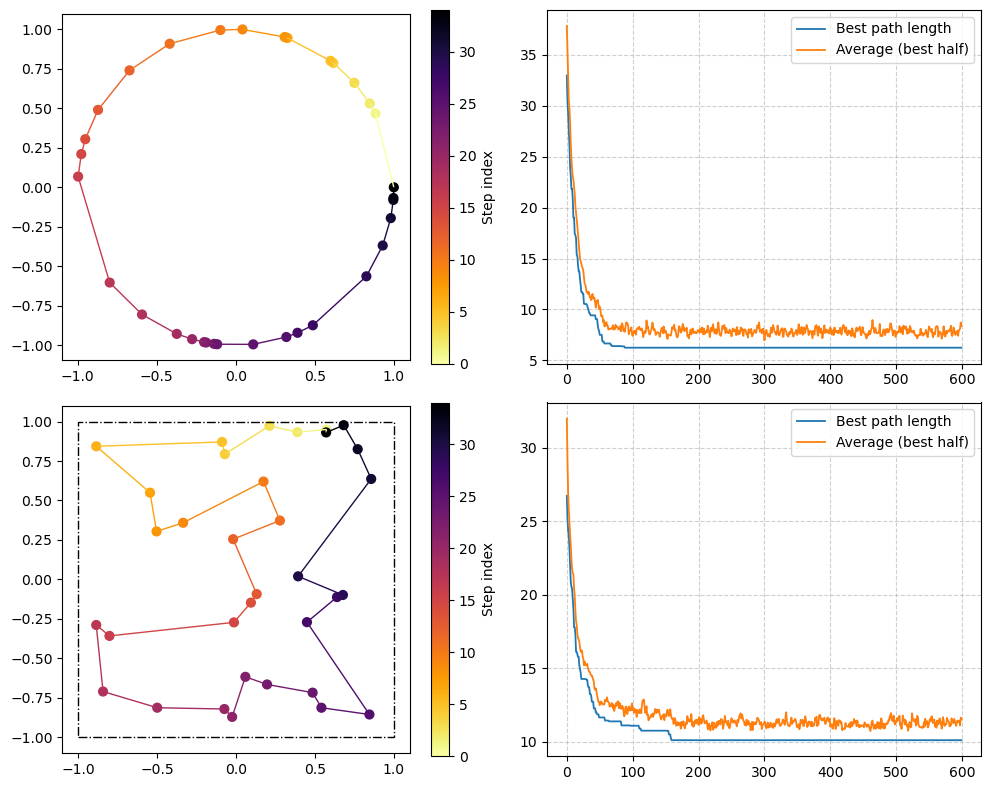

In [13]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

data = np.loadtxt("circle_best_path.dat")
x = data[:, 0]
y = data[:, 1]

points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
lc = LineCollection(segments, cmap='inferno_r', linewidth=1, array=np.arange(len(x)))
axs[0,0].add_collection(lc)

sc = axs[0,0].scatter(x, y, c=np.arange(len(x)), cmap='inferno_r', s=40)
axs[0,0].set_aspect('equal')
fig.colorbar(sc, ax=axs[0,0], label="Step index") 

data = np.loadtxt("circle_losses.dat")
gen  = data[:,0]
best = data[:,1]
avg  = data[:,2]

axs[0,1].plot(gen, best, label="Best path length", linewidth=1.3)
axs[0,1].plot(gen, avg, label="Average (best half)", linewidth=1.3)
axs[0,1].legend()
axs[0,1].grid(True, linestyle='--', alpha=0.6)

data = np.loadtxt("square_best_path.dat")
x = data[:, 0]
y = data[:, 1]

points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
lc = LineCollection(segments, cmap='inferno_r', linewidth=1, array=np.arange(len(x)))
axs[1,0].add_collection(lc)

sc = axs[1,0].scatter(x, y, c=np.arange(len(x)), cmap='inferno_r', s=40)
axs[1,0].set_aspect('equal')
fig.colorbar(sc, ax=axs[1,0], label="Step index")  

data = np.loadtxt("square_losses.dat")
gen  = data[:,0]
best = data[:,1]
avg  = data[:,2]

axs[1,1].plot(gen, best, label="Best path length", linewidth=1.3)
axs[1,1].plot(gen, avg, label="Average (best half)", linewidth=1.3)
axs[1,1].legend()
axs[1,1].grid(True, linestyle='--', alpha=0.6)
square = Rectangle((-1, -1), 2, 2,
                   fill=False,
                   edgecolor='black',
                   linestyle='-.',
                   linewidth=1)

axs[1,0].add_patch(square)

plt.tight_layout()
plt.show()